# Imports

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from scipy.stats import boxcox

# Settings:

In [70]:
pd.options.display.max_rows

60

# Dataset

In [71]:
# Load the dataset)
taxi_data = sns.load_dataset('taxis')

- pickup - Datetime when the taxi was picked up
- dropoff - Datetime when the taxi was dropped off
- passengers - Number of passengers in the trip
- distance - Trip distance in miles
- fare - Base fare amount in dollars
- tip - Tip amount in dollars
- tolls - Tolls paid in dollars
- total - Total fare (includes fare, tip, and tolls)
- color - Taxi color (yellow or green)
- payment - Payment method (credit card or cash)
- pickup_zone - Pickup neighborhood in NYC
- dropoff_zone - Dropoff neighborhood in NYC
- pickup_borough - Pickup borough (Manhattan, Queens, etc.)
- dropoff_borough - Dropoff borough

# EDA

In [72]:
# Taxi dataset information
taxi_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


## Observations:
### Initial Observations
- Dataset has 6433 rows. 
- The following columns have null values:
    - payment, pickup_zone, dropoff_zone, pickup_borough, dropoff_borough
- Datatypes seems ok, will review. 

In [73]:
## Display the first few rows of the dataset
taxi_data.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


### Updated Observations:
- Dataset has 6433 rows. 
- The following columns have null values:
    - payment, pickup_zone, dropoff_zone, pickup_borough, dropoff_borough
- Datatypes seems ok, will review. 
- *New*
- Pickup and dropoff are full datetime fields < I will need to validate dropoff is later than pickup >
- total seems related to fare, tip and tolls, but there are differences
- Payment reflects how paid

In [74]:
taxi_data.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


### Further Observations:
- Dataset has 6433 rows. 
- The following columns have null values:
    - payment, pickup_zone, dropoff_zone, pickup_borough, dropoff_borough
- Datatypes seems ok, will review. 
- *New*
- Pickup and dropoff are full datetime fields < I will need to validate dropoff is later than pickup >
- total seems related to fare, tip and tolls, but there are differences
- Payment reflects how paid
- *New*
- Some 0 min passengers need exploring
- Some 0 distance need exploring
- Quite a large range on fare, consider outliers
- total has a larger range too, consider outliers

### Visual Dashboard

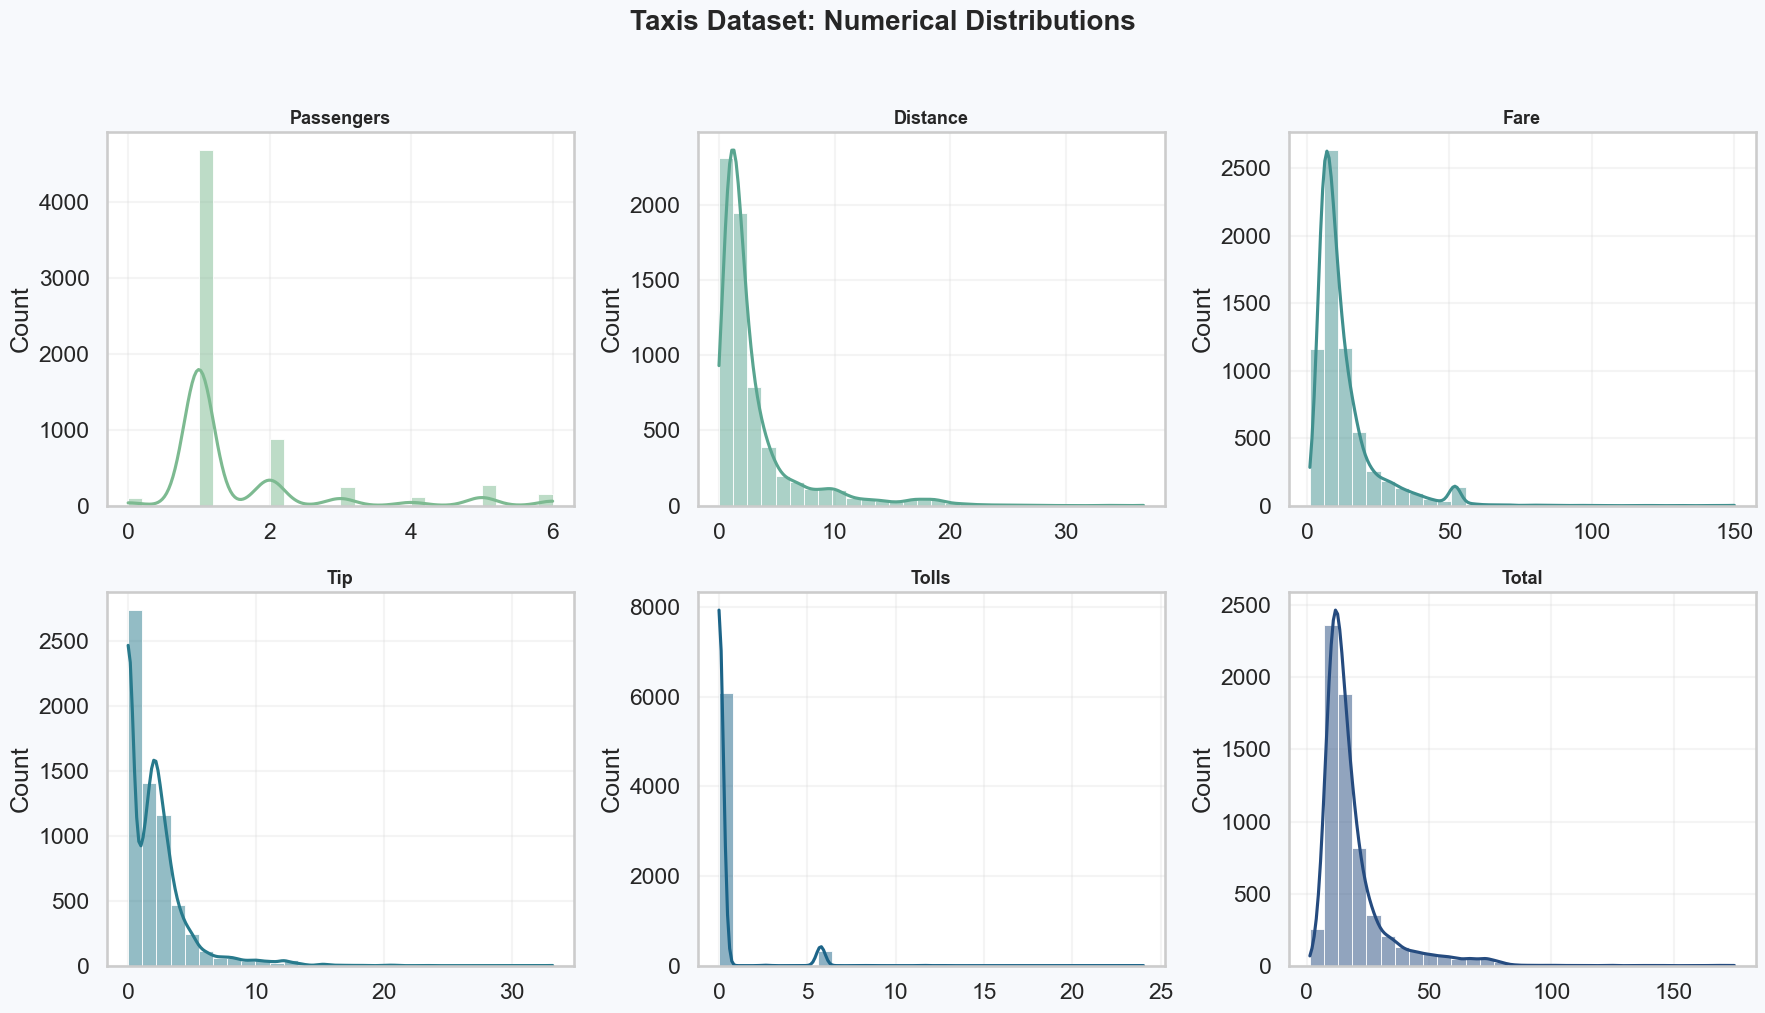

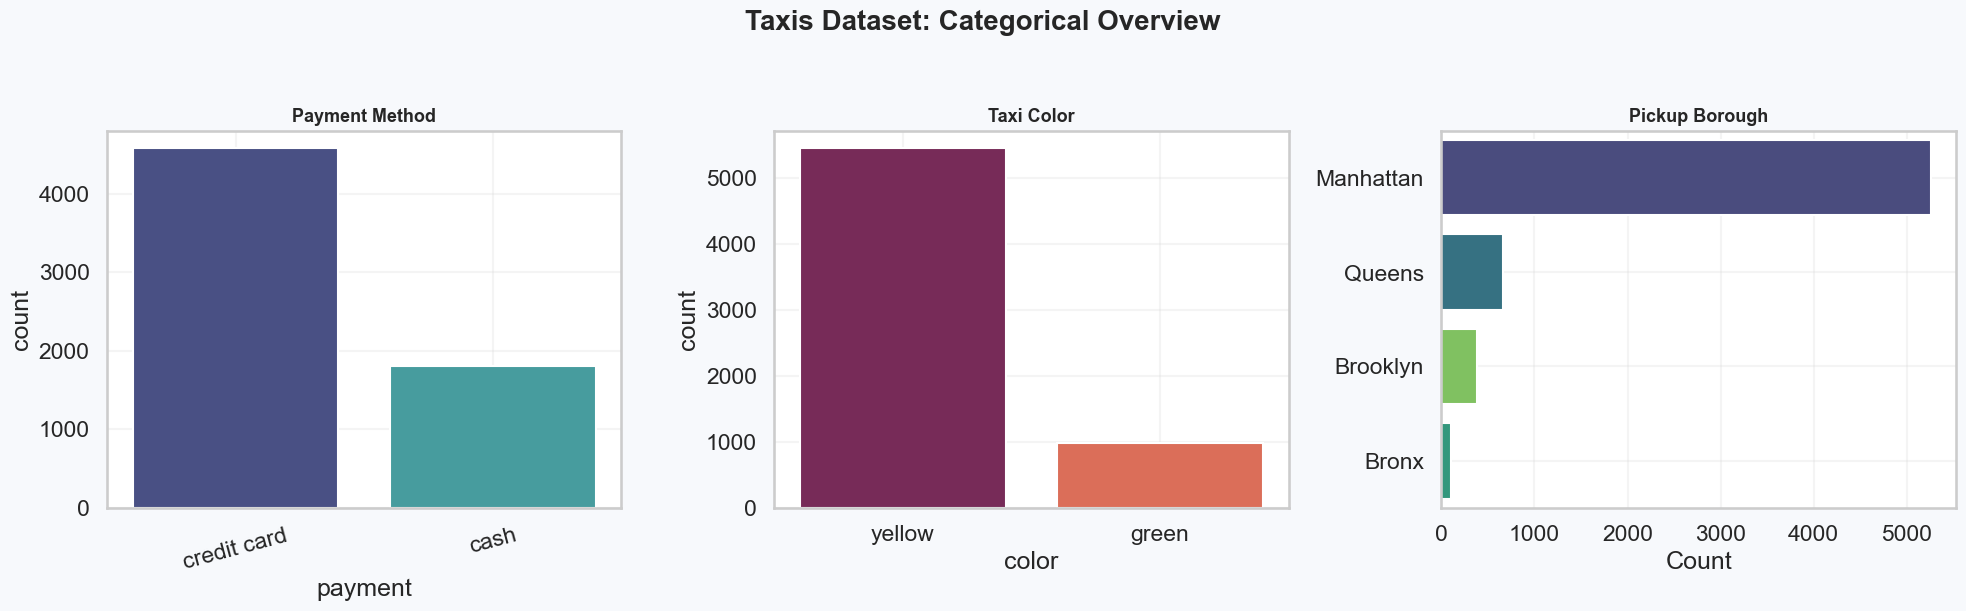

In [75]:
# Polished EDA dashboard
sns.set_theme(style="whitegrid", context="talk")

num_cols = ["passengers", "distance", "fare", "tip", "tolls", "total"]
palette = sns.color_palette("crest", n_colors=len(num_cols))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor="#f7f9fc")
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=taxi_data,
        x=col,
        bins=30,
        kde=True,
        color=palette[i],
        edgecolor="white",
        linewidth=0.6,
        ax=axes[i],
    )
    axes[i].set_title(col.replace("_", " ").title(), fontsize=13, weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].grid(alpha=0.2)

fig.suptitle("Taxis Dataset: Numerical Distributions", fontsize=20, weight="bold", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#f7f9fc")

payment_order = taxi_data["payment"].value_counts(dropna=True).index
sns.countplot(
    data=taxi_data,
    x="payment",
    hue="payment",
    order=payment_order,
    palette="mako",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Payment Method", fontsize=13, weight="bold")
axes[0].tick_params(axis="x", rotation=15)

color_order = taxi_data["color"].value_counts(dropna=True).index
sns.countplot(
    data=taxi_data,
    x="color",
    hue="color",
    order=color_order,
    palette="rocket",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Taxi Color", fontsize=13, weight="bold")

borough_order = taxi_data["pickup_borough"].value_counts(dropna=True).index
sns.countplot(
    data=taxi_data,
    y="pickup_borough",
    hue="pickup_borough",
    order=borough_order,
    palette="viridis",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Pickup Borough", fontsize=13, weight="bold")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("")

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle("Taxis Dataset: Categorical Overview", fontsize=20, weight="bold", y=1.03)
fig.tight_layout()
plt.show()

In [76]:
# Validate skewness of numerical features
taxi_data[["passengers","distance","fare","tip","tolls","total"]].skew(numeric_only=True)

passengers    2.359143
distance      3.008206
fare          3.217463
tip           2.665152
tolls         5.074936
total         3.093333
dtype: float64

# Data Cleansing

### Compare dropoff with pickup

In [77]:
# Validate that dropoff is greater than pickup
taxi_data["dropoff_greater"] = taxi_data["dropoff"] > taxi_data["pickup"]
taxi_data["dropoff_greater"].value_counts()

dropoff_greater
True     6427
False       6
Name: count, dtype: int64

In [78]:
# Review the 6 entries where dropoff is not greater than pickup
taxi_data[~taxi_data["dropoff_greater"]]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,dropoff_greater
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.0,72.0,0.0,0.0,72.0,yellow,NaN,East New York,NaN,Brooklyn,NaN,False
5493,2019-03-06 12:14:00,2019-03-06 12:14:00,1,0.0,10.0,0.0,0.0,10.0,green,credit card,NaN,NaN,NaN,NaN,False
5624,2019-03-11 14:04:50,2019-03-11 14:04:50,1,0.0,2.5,0.0,0.0,3.3,green,cash,NaN,NaN,NaN,NaN,False
5638,2019-03-13 12:22:00,2019-03-13 12:22:00,1,0.0,10.0,0.0,0.0,10.0,green,credit card,NaN,NaN,NaN,NaN,False
6083,2019-03-19 15:34:00,2019-03-19 15:34:00,1,0.0,5.0,0.0,0.0,5.0,green,credit card,NaN,NaN,NaN,NaN,False
6356,2019-03-01 16:58:23,2019-03-01 16:58:23,1,0.0,3.0,0.0,0.0,4.8,green,cash,Stuyvesant Heights,NaN,Brooklyn,NaN,False


#### Conclusion
Each of these have 0 distance, and a multitude of NaN values across different features. 
It would be best to drop these values from the main dataset as offer little value. 

In [79]:
# Rows where dropoff is not after pickup
invalid_mask = taxi_data["dropoff"] <= taxi_data["pickup"]
print("Invalid rows:", invalid_mask.sum())  # expected: 6

# Keep only valid rows and reset index for cleaner downstream work
taxi_data = taxi_data.loc[~invalid_mask].copy().reset_index(drop=True)

# Remove helper column
taxi_data.drop(columns=["dropoff_greater"], errors="ignore", inplace=True)

# Post-clean validation checks
assert (taxi_data["dropoff"] > taxi_data["pickup"]).all(), "Found invalid pickup/dropoff ordering"
print("Rows after dropoff cleanup:", len(taxi_data))

taxi_data.info()

Invalid rows: 6
Rows after dropoff cleanup: 6427
<class 'pandas.DataFrame'>
RangeIndex: 6427 entries, 0 to 6426
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6427 non-null   datetime64[us]
 1   dropoff          6427 non-null   datetime64[us]
 2   passengers       6427 non-null   int64         
 3   distance         6427 non-null   float64       
 4   fare             6427 non-null   float64       
 5   tip              6427 non-null   float64       
 6   tolls            6427 non-null   float64       
 7   total            6427 non-null   float64       
 8   color            6427 non-null   str           
 9   payment          6384 non-null   str           
 10  pickup_zone      6405 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6405 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes:

### Clear null values
    - payment, pickup_zone, dropoff_zone, pickup_borough, dropoff_borough


In [80]:
# Review null values
taxi_data.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            43
pickup_zone        22
dropoff_zone       39
pickup_borough     22
dropoff_borough    39
dtype: int64

#### payment null values

In [81]:
# Investigate nulls in payment column
taxi_data[taxi_data["payment"].isnull()]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
7,2019-03-22 12:47:13,2019-03-22 12:58:17,0,1.4,8.5,0.0,0.00,11.80,yellow,NaN,Murray Hill,Flatiron,Manhattan,Manhattan
445,2019-03-19 06:57:14,2019-03-19 07:00:08,1,1.3,5.5,0.0,0.00,6.30,yellow,NaN,Boerum Hill,Columbia Street,Brooklyn,Brooklyn
491,2019-03-07 07:11:33,2019-03-07 07:11:39,1,1.6,2.5,0.0,0.00,5.80,yellow,NaN,Murray Hill,Murray Hill,Manhattan,Manhattan
545,2019-03-27 11:03:43,2019-03-27 11:14:34,1,4.2,15.0,0.0,0.00,15.80,yellow,NaN,LaGuardia Airport,Forest Hills,Queens,Queens
621,2019-03-15 17:16:35,2019-03-15 17:25:01,1,1.3,7.5,0.0,0.00,11.80,yellow,NaN,Upper East Side North,Upper East Side South,Manhattan,Manhattan
770,2019-03-02 03:16:59,2019-03-02 03:17:06,0,9.4,2.5,0.0,0.00,3.80,yellow,NaN,JFK Airport,JFK Airport,Queens,Queens
913,2019-03-23 11:26:58,2019-03-23 11:35:17,2,1.3,7.5,0.0,0.00,10.80,yellow,NaN,Upper East Side South,Lincoln Square West,Manhattan,Manhattan
953,2019-03-08 02:58:37,2019-03-08 03:19:27,2,6.9,23.5,0.0,0.00,27.30,yellow,NaN,Garment District,Central Harlem North,Manhattan,Manhattan
1207,2019-03-08 15:41:20,2019-03-08 15:41:23,1,0.0,2.5,0.0,0.00,5.80,yellow,NaN,Hudson Sq,Hudson Sq,Manhattan,Manhattan
1372,2019-03-12 09:19:44,2019-03-12 09:43:09,1,1.6,14.5,0.0,0.00,17.80,yellow,NaN,Midtown East,Garment District,Manhattan,Manhattan


In [82]:
## compare null vs non-null payment entries to see how split between cash and card payments may differ and print ratios 
payment_counts = taxi_data["payment"].value_counts(dropna=False)
print(payment_counts)

payment_ratios = payment_counts / len(taxi_data)
print(payment_ratios)


payment
credit card    4574
cash           1810
NaN              43
Name: count, dtype: int64
payment
credit card    0.711685
cash           0.281624
NaN            0.006691
Name: count, dtype: float64


#### Conclusion
There is important data worth keeping. 
I dont want to assign all to majority "credit card" as instills bias. Will randomaly distribute based on the current ratio split. 

In [83]:
# Reproducible, row-wise proportional imputation for payment
rng = np.random.default_rng(42)

# Use observed non-null distribution
payment_probs = taxi_data["payment"].value_counts(normalize=True)
labels = payment_probs.index.to_list()
probs = payment_probs.values

missing_mask = taxi_data["payment"].isna()
missing_n = int(missing_mask.sum())
print("Missing payment rows before:", missing_n)

if missing_n > 0:
    taxi_data.loc[missing_mask, "payment"] = rng.choice(labels, size=missing_n, p=probs)

print("Missing payment rows after:", int(taxi_data["payment"].isna().sum()))
print(taxi_data["payment"].value_counts(normalize=True))

Missing payment rows before: 43
Missing payment rows after: 0
payment
credit card    0.716042
cash           0.283958
Name: proportion, dtype: float64


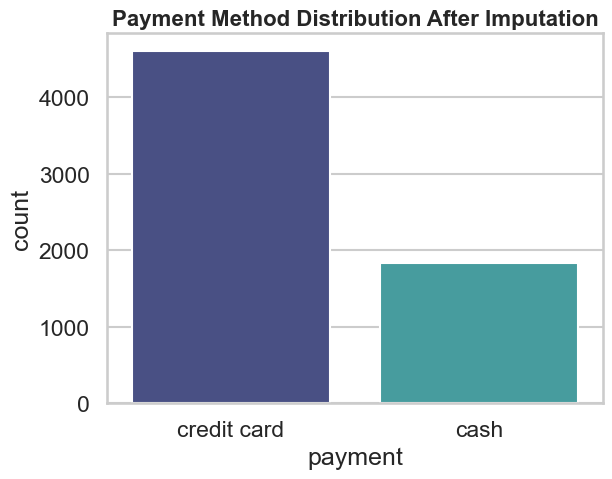

In [84]:
# Review and visualize the results 
sns.countplot(
    data=taxi_data,
    x="payment",
    hue="payment",  
    palette="mako",
    legend=False 
)
plt.title("Payment Method Distribution After Imputation", fontsize=16, weight="bold")
plt.show()

### Investigate total target feature
- total seems related to fare, tip and tolls, but there are differences

### Investigate 0 min passengers and distance:
- Some 0 min passengers need exploring
- Some 0 distance need exploring

### Investigate fare values
- Quite a large range on fare, consider outliers

### Investigate total range values
- total has a larger range too, consider outliers